In [2]:
import numpy as np
import pandas as pd
import matplotlib as pyplot
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving BAJFINANCE.NS (4).csv to BAJFINANCE.NS (4).csv


In [4]:
df = pd.read_csv('BAJFINANCE.NS (4).csv')

In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

display(df.head())

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,DayOfWeek
0,2002-07-02,5.523439,5.537041,5.421423,5.443769,4.009640,61044.0,2002,7,2,1
1,2002-07-03,5.505950,5.545785,5.328151,5.466116,4.026099,34160.0,2002,7,3,2
2,2002-07-04,5.501093,5.572018,5.417537,5.528297,4.071899,27892.0,2002,7,4,3
3,2002-07-05,5.563274,5.656546,5.474860,5.590478,4.117700,58976.0,2002,7,5,4
4,2002-07-08,5.501093,5.718727,5.501093,5.625455,4.143462,48909.0,2002,7,8,0


### Feature Engineering: Adding Technical Indicators

In [17]:
# Sort the DataFrame by Date to ensure correct calculation of time-series features
df = df.sort_values(by='Date').reset_index(drop=True)

# 1. Simple Moving Averages (SMA)
# Calculate 5-day, 10-day, and 20-day Simple Moving Averages for 'Close' price
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# 2. Daily Returns
# Calculate the percentage change in 'Close' price from the previous day
df['Daily_Return'] = df['Close'].pct_change() * 100

# 3. Volatility (Standard Deviation of Daily Returns over a period)
# Calculate 5-day and 10-day rolling standard deviation of daily returns
df['Volatility_5'] = df['Daily_Return'].rolling(window=5).std()
df['Volatility_10'] = df['Daily_Return'].rolling(window=10).std()

# 4. Lagged Close Price
# Previous day's closing price
df['Lag_Close_1'] = df['Close'].shift(1)

# Display the first few rows with the newly engineered features
# Note: The initial rows will have NaN for moving averages and lagged features
display(df.head(25))

/tmp/ipykernel_1137/3660398779.py:12: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Daily_Return'] = df['Close'].pct_change() * 100


,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,DayOfWeek,SMA_5,SMA_10,SMA_20,Daily_Return,Volatility_5,Volatility_10,Lag_Close_1
0,2002-07-02,5.523439,5.537041,5.421423,5.443769,4.009640,61044.0,2002,7,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2002-07-03,5.505950,5.545785,5.328151,5.466116,4.026099,34160.0,2002,7,3,2,NaN,NaN,NaN,0.410506,NaN,NaN,5.443769
2,2002-07-04,5.501093,5.572018,5.417537,5.528297,4.071899,27892.0,2002,7,4,3,NaN,NaN,NaN,1.137572,NaN,NaN,5.466116
3,2002-07-05,5.563274,5.656546,5.474860,5.590478,4.117700,58976.0,2002,7,5,4,NaN,NaN,NaN,1.124777,NaN,NaN,5.528297
4,2002-07-08,5.501093,5.718727,5.501093,5.625455,4.143462,48909.0,2002,7,8,0,5.530823,NaN,NaN,0.625653,NaN,NaN,5.590478
5,2002-07-09,5.590478,5.758562,5.568132,5.616711,4.137022,321846.0,2002,7,9,1,5.565411,NaN,NaN,-0.155436,0.540262,NaN,5.625455
6,2002-07-10,5.488462,5.488462,5.146465,5.222249,3.846478,138434.0,2002,7,10,2,5.516638,NaN,NaN,-7.023007,3.486253,NaN,5.616711
7,2002-07-11,4.978382,5.213504,4.978382,5.186300,3.820000,15027.0,2002,7,11,3,5.448239,NaN,NaN,-0.688382,3.316442,NaN,5.222249
8,2002-07-12,5.501093,5.501093,5.244595,5.319407,3.918040,24187.0,2002,7,12,4,5.394024,NaN,NaN,2.566512,3.620379,NaN,5.186300
9,2002-07-15,5.324265,5.479718,5.191158,5.333009,3.928059,50330.0,2002,7,15,0,5.335535,5.433179,NaN,0.255705,3.584111,NaN,5.319407


After adding new features, it's important to handle any `NaN` values that resulted from the rolling window calculations or lagged features. We'll drop these rows to ensure a clean dataset for subsequent modeling steps.

In [18]:
# Drop rows with NaN values that resulted from feature engineering
# This will remove the initial rows for which moving averages/lagged features could not be calculated
df_featured = df.dropna().reset_index(drop=True)

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after feature engineering and dropping NaNs: {df_featured.shape}")
display(df_featured.head())

Original DataFrame shape: (4995, 18)
DataFrame shape after feature engineering and dropping NaNs: (4776, 18)


,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,DayOfWeek,SMA_5,SMA_10,SMA_20,Daily_Return,Volatility_5,Volatility_10,Lag_Close_1
0,2002-07-29,4.223463,4.250667,3.903813,4.250667,3.130853,17188.0,2002,7,29,0,4.819043,4.966043,5.199611,-12.744329,5.920029,4.444792,4.871508
1,2002-07-30,4.170026,4.325479,4.036920,4.276900,3.150176,66561.0,2002,7,30,1,4.662035,4.862181,5.141267,0.617150,5.707670,4.497525,4.250667
2,2002-07-31,4.179742,4.303133,4.148651,4.210833,3.101514,5557.0,2002,7,31,2,4.491814,4.778819,5.078503,-1.544740,5.532022,4.368644,4.276900
3,2002-08-01,4.250667,4.516881,4.250667,4.458586,3.283998,31134.0,2002,8,1,3,4.413699,4.716638,5.025018,5.883705,6.878903,4.952689,4.210833
4,2002-08-02,4.068010,4.610153,4.068010,4.498421,3.313338,28211.0,2002,8,2,4,4.339081,4.651348,4.970415,0.893445,6.911832,4.926111,4.458586


In [19]:
from sklearn.model_selection import train_test_split
import numpy as np

# Use df_featured which already has engineered features and NaNs handled
# Define features (X) and target (y)
feature_columns = ['Open', 'High', 'Low', 'Volume', 'Year', 'Month', 'Day', 'DayOfWeek',
                   'SMA_5', 'SMA_10', 'SMA_20', 'Daily_Return', 'Volatility_5', 'Volatility_10', 'Lag_Close_1']

X = df_featured[feature_columns]
y = df_featured['Close']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 3820 samples
Test set size: 956 samples


In [20]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the ExtraTreesRegressor model
extra_tree_model = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model with the new features
extra_tree_model.fit(X_train, y_train)

print("ExtraTreesRegressor model re-trained successfully with new features!")

ExtraTreesRegressor model re-trained successfully with new features!


Mean Squared Error (MSE) with new features: 480.69
R-squared (R2) with new features: 1.00


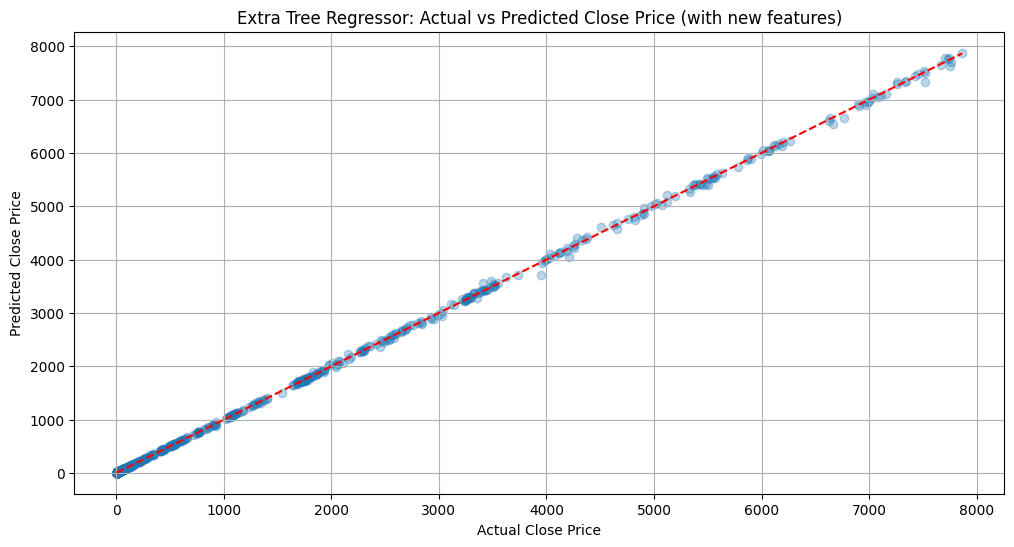

In [21]:
# Make predictions on the test set with the re-trained model
y_pred = extra_tree_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) with new features: {mse:.2f}")
print(f"R-squared (R2) with new features: {r2:.2f}")

# Visualize predictions vs actual values
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Extra Tree Regressor: Actual vs Predicted Close Price (with new features)')
plt.grid(True)
plt.show()

### Implement Isolation Forest for Anomaly Detection

In [22]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

isolation_forest = IsolationForest(random_state=42, contamination=0.01)

# Train the Isolation Forest model with the new features
isolation_forest.fit(X_train)

print("Isolation Forest model re-trained successfully with new features!")

Isolation Forest model re-trained successfully with new features!


In [23]:
# Predict anomalies (-1 for outlier, 1 for inlier) on the full feature set
# First, re-create df_cleaned_xy to ensure it aligns with the current X and y after feature engineering.
# Note: This step re-uses the df_featured which contains all new features.

# We need to use the `X` (from df_featured) for prediction.
# To combine `X` and `y` back for anomaly detection, we need to ensure consistent indexing.
# Since X and y were derived from df_featured, we can reconstruct a temporary DataFrame for anomaly processing.

# Create a temporary DataFrame for anomaly detection which includes all features and the target
temp_df_for_anomaly = X.copy()
temp_df_for_anomaly['Close'] = y.copy()

# Get anomaly scores for the entire dataset
temp_df_for_anomaly['anomaly_score'] = isolation_forest.decision_function(X)

# Predict anomalies (-1 for outlier, 1 for inlier) for the entire dataset
temp_df_for_anomaly['is_anomaly'] = isolation_forest.predict(X)

# Filter out the anomalies
anomalies_new_features = temp_df_for_anomaly[temp_df_for_anomaly['is_anomaly'] == -1]

print(f"Number of detected anomalies with new features: {len(anomalies_new_features)}")
display(anomalies_new_features.head())

Number of detected anomalies with new features: 45


,Open,High,Low,Volume,Year,Month,Day,DayOfWeek,SMA_5,SMA_10,SMA_20,Daily_Return,Volatility_5,Volatility_10,Lag_Close_1,Close,anomaly_score,is_anomaly
4194,2656.750000,2700.000000,2225.0,4844235.0,2020,3,23,0,2894.070020,3388.695020,3960.515039,-23.230801,11.047086,8.849151,2951.899902,2266.149902,-0.015317,-1
4198,2955.000000,3040.000000,2500.0,7170609.0,2020,3,27,4,2532.389990,2853.840015,3520.320032,-8.998815,13.855894,10.658840,2793.699951,2542.300049,-0.011731,-1
4199,2390.050049,2414.399902,2226.0,7698355.0,2020,3,30,0,2527.580029,2710.825024,3409.132532,-11.808203,9.868855,10.923145,2542.300049,2242.100098,-0.022250,-1
4200,2305.100098,2340.000000,2100.0,11043111.0,2020,3,31,1,2475.900049,2587.920020,3301.885034,-1.173010,8.500821,10.938950,2242.100098,2215.800049,-0.004413,-1
4564,7445.500000,7679.950195,7360.0,3474969.0,2021,9,17,4,7423.509863,7449.844922,7272.170020,0.233418,0.244633,0.322992,7411.500000,7428.799805,-0.012865,-1


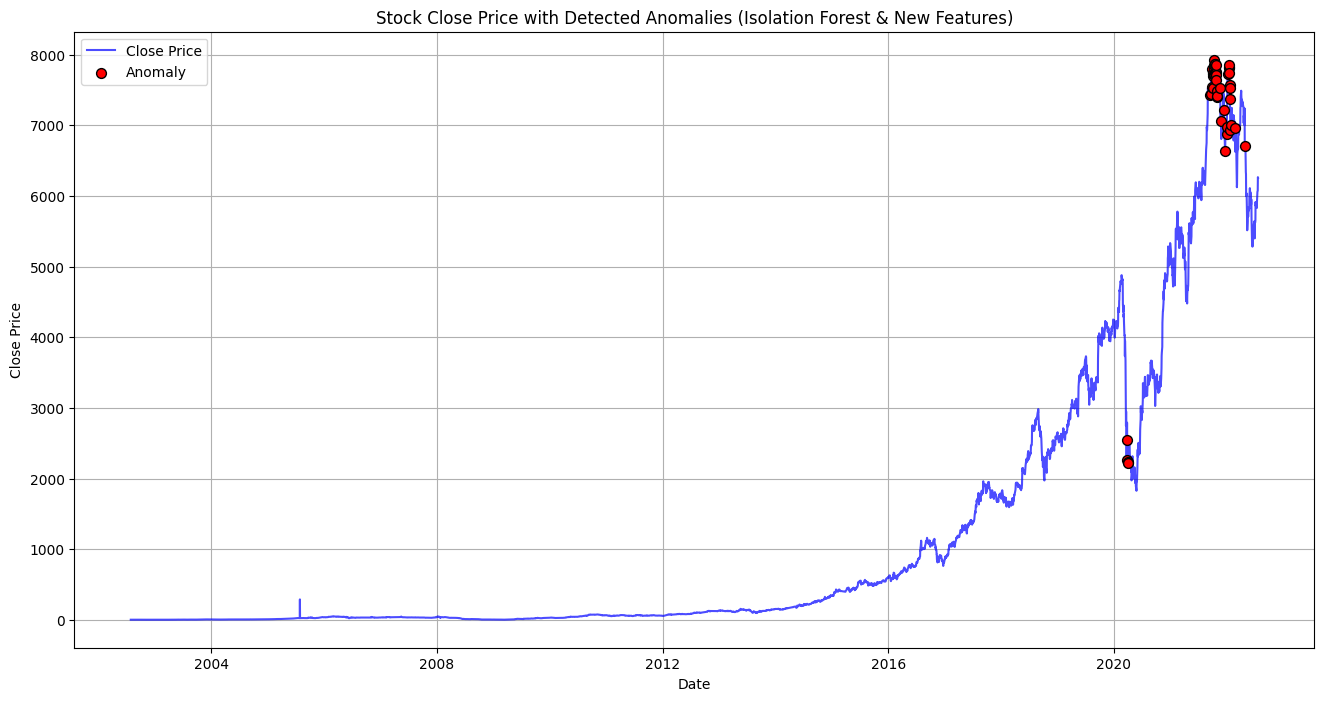

In [24]:
# To plot anomalies, we need the 'Date' column from the original df_featured
# Create a DataFrame for plotting, including 'Date', 'Close', and anomaly flags
plot_df_anomalies = df_featured[['Date', 'Close']].copy()
# Merge the anomaly results back to the original full DataFrame (df_featured) based on index
plot_df_anomalies = plot_df_anomalies.join(temp_df_for_anomaly[['is_anomaly', 'anomaly_score']])

plt.figure(figsize=(16, 8))
plt.plot(plot_df_anomalies['Date'], plot_df_anomalies['Close'], label='Close Price', color='blue', alpha=0.7)
plt.scatter(
    plot_df_anomalies[plot_df_anomalies['is_anomaly'] == -1]['Date'],
    plot_df_anomalies[plot_df_anomalies['is_anomaly'] == -1]['Close'],
    color='red', label='Anomaly', marker='o', s=50, edgecolors='black', zorder=5
)

plt.title('Stock Close Price with Detected Anomalies (Isolation Forest & New Features)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
df.shape

(4995, 11)